## Setup and Imports

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config.base_config import BaseConfig
from evaluation.evaluate import evaluate

sns.set_theme(style="whitegrid")

# RL models
from agents.rl.train_ppo import train_ppo
from agents.rl.train_sac import train_sac
from agents.rl.train_td3 import train_td3
from agents.rl.train_ddpg import train_ddpg
from agents.rl.train_cvar import train_cvar

# Non-RL baselines
from agents.baselines.static_6040 import Static6040
from agents.baselines.age_glide_path import GlidePath

## Load Market and User Profile Data

In [3]:
market_df = pd.read_csv("../data/processed/market_data.csv")
user_df = pd.read_csv("../data/processed/user_profiles.csv")

print("Market data shape:", market_df.shape)
print("User data shape:", user_df.shape)

Market data shape: (229, 7)
User data shape: (20000, 9)


#### Market data exploration

In [93]:
market_df.head()

,Date,equity_return,debt_return,cash_return,volatility,drawdown,market_indicator
0,2007-01-01,0.0293,0.0441,0.0025,0.061391,0.000000,2
1,2007-02-01,-0.0826,0.0074,0.0025,0.065611,-0.082641,1
2,2007-03-01,0.0204,0.0182,0.0025,0.064439,-0.063965,2
3,2007-04-01,0.0697,0.0180,0.0025,0.061713,0.000000,2
4,2007-05-01,0.0509,-0.0048,0.0025,0.060363,0.000000,2


In [94]:
market_df.describe()

,equity_return,debt_return,cash_return,volatility,drawdown,market_indicator
count,229.000000,229.000000,229.0000,229.000000,229.000000,229.000000
mean,0.009891,0.000198,0.0025,0.056319,-0.080346,1.314410
std,0.059106,0.029689,0.0000,0.023002,0.108954,0.692575
min,-0.264100,-0.170600,0.0025,0.030889,-0.551184,0.000000
25%,-0.020700,-0.014500,0.0025,0.039207,-0.108584,1.000000
50%,0.009300,-0.000500,0.0025,0.044687,-0.042151,1.000000
75%,0.042300,0.014200,0.0025,0.070572,0.000000,2.000000
max,0.280700,0.120400,0.0025,0.121332,0.000000,2.000000


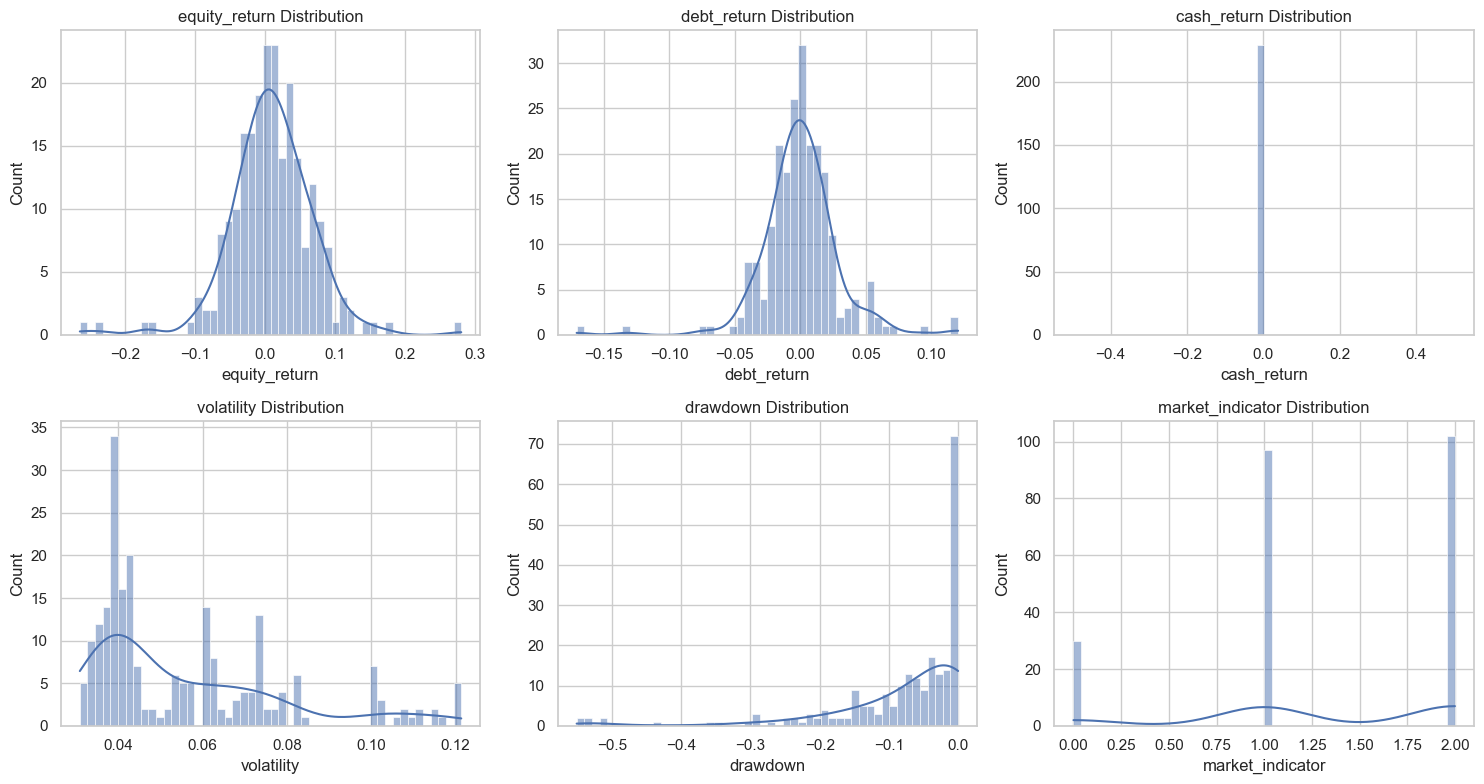

In [97]:
# Market distributions plot

def plot_market_distributions(df):
    cols = df.columns.drop("Date")

    n_cols = 3
    n_rows = (len(cols) + 2) // 3

    plt.figure(figsize=(15, 4 * n_rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=50)
        plt.title(f"{col} Distribution")

    plt.tight_layout()
    plt.show()

plot_market_distributions(market_df)

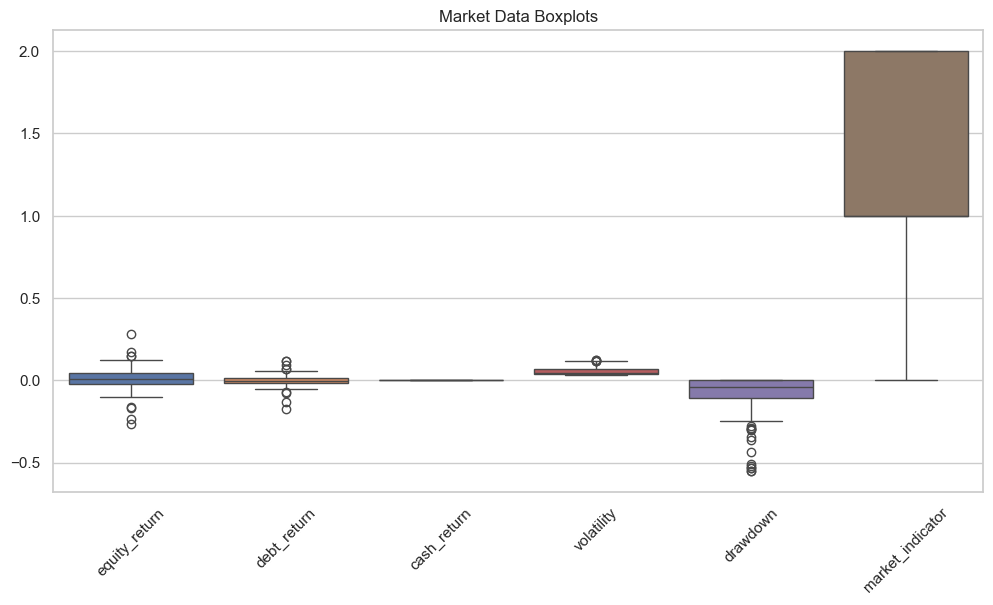

In [98]:
# Market data box plots

plt.figure(figsize=(12, 6))
sns.boxplot(data=market_df.drop(columns=["Date"]))
plt.title("Market Data Boxplots")
plt.xticks(rotation=45)
plt.show()

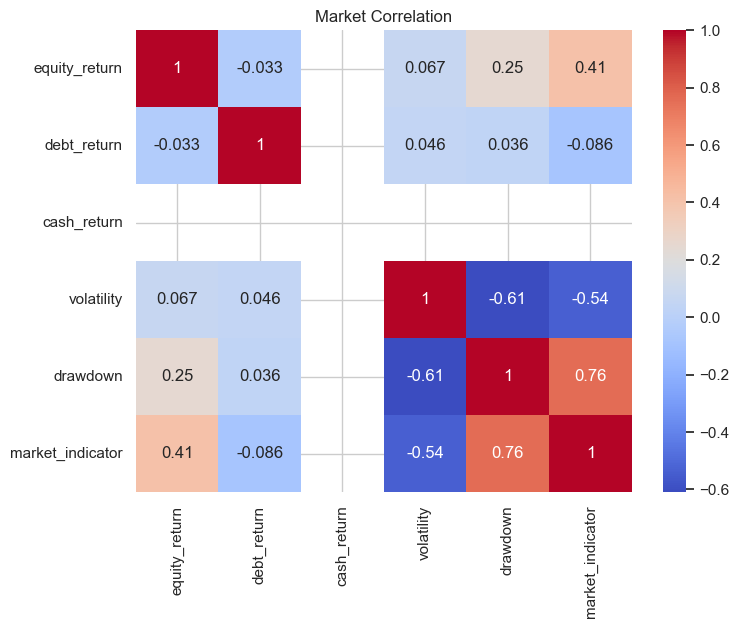

In [101]:
# Market data correlation plots

plt.figure(figsize=(8, 6))
sns.heatmap(market_df.drop(columns=["Date"]).corr(), annot=True, cmap="coolwarm")
plt.title("Market Correlation")
plt.show()

#### User data exploration

In [102]:
user_df.head()

,wealth,age,goal,income,income_var,job_loss_prob,expense,emergency_buffer_months,risk_appetite
0,1670689,52,168,35765,0.30,0.008,32138,22,0.3
1,11456686,47,228,96369,0.15,0.004,55982,9,0.5
2,18344126,44,264,240095,0.05,0.001,126106,4,0.3
3,1469946,41,300,59394,0.05,0.001,46084,4,0.7
4,7573057,34,384,161107,0.05,0.001,76412,5,0.7


In [103]:
user_df.describe()

,wealth,age,goal,income,income_var,job_loss_prob,expense,emergency_buffer_months,risk_appetite
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1.528445e+07,40.476500,306.282000,99806.652200,0.135997,0.002629,60653.837800,8.035150,0.476420
std,3.038904e+07,11.008711,132.104526,73602.249429,0.084846,0.002112,37145.276425,4.013181,0.151067
min,0.000000e+00,22.000000,84.000000,20000.000000,0.050000,0.001000,11870.000000,4.000000,0.300000
25%,6.877405e+05,31.000000,192.000000,49040.500000,0.050000,0.001000,36018.000000,6.000000,0.300000
50%,3.744092e+06,40.000000,312.000000,75238.000000,0.150000,0.001000,48937.500000,7.000000,0.500000
75%,1.394271e+07,50.000000,420.000000,122527.250000,0.150000,0.004000,72416.250000,9.000000,0.500000
max,3.056249e+08,59.000000,528.000000,488849.000000,0.300000,0.008000,286121.000000,23.000000,0.700000


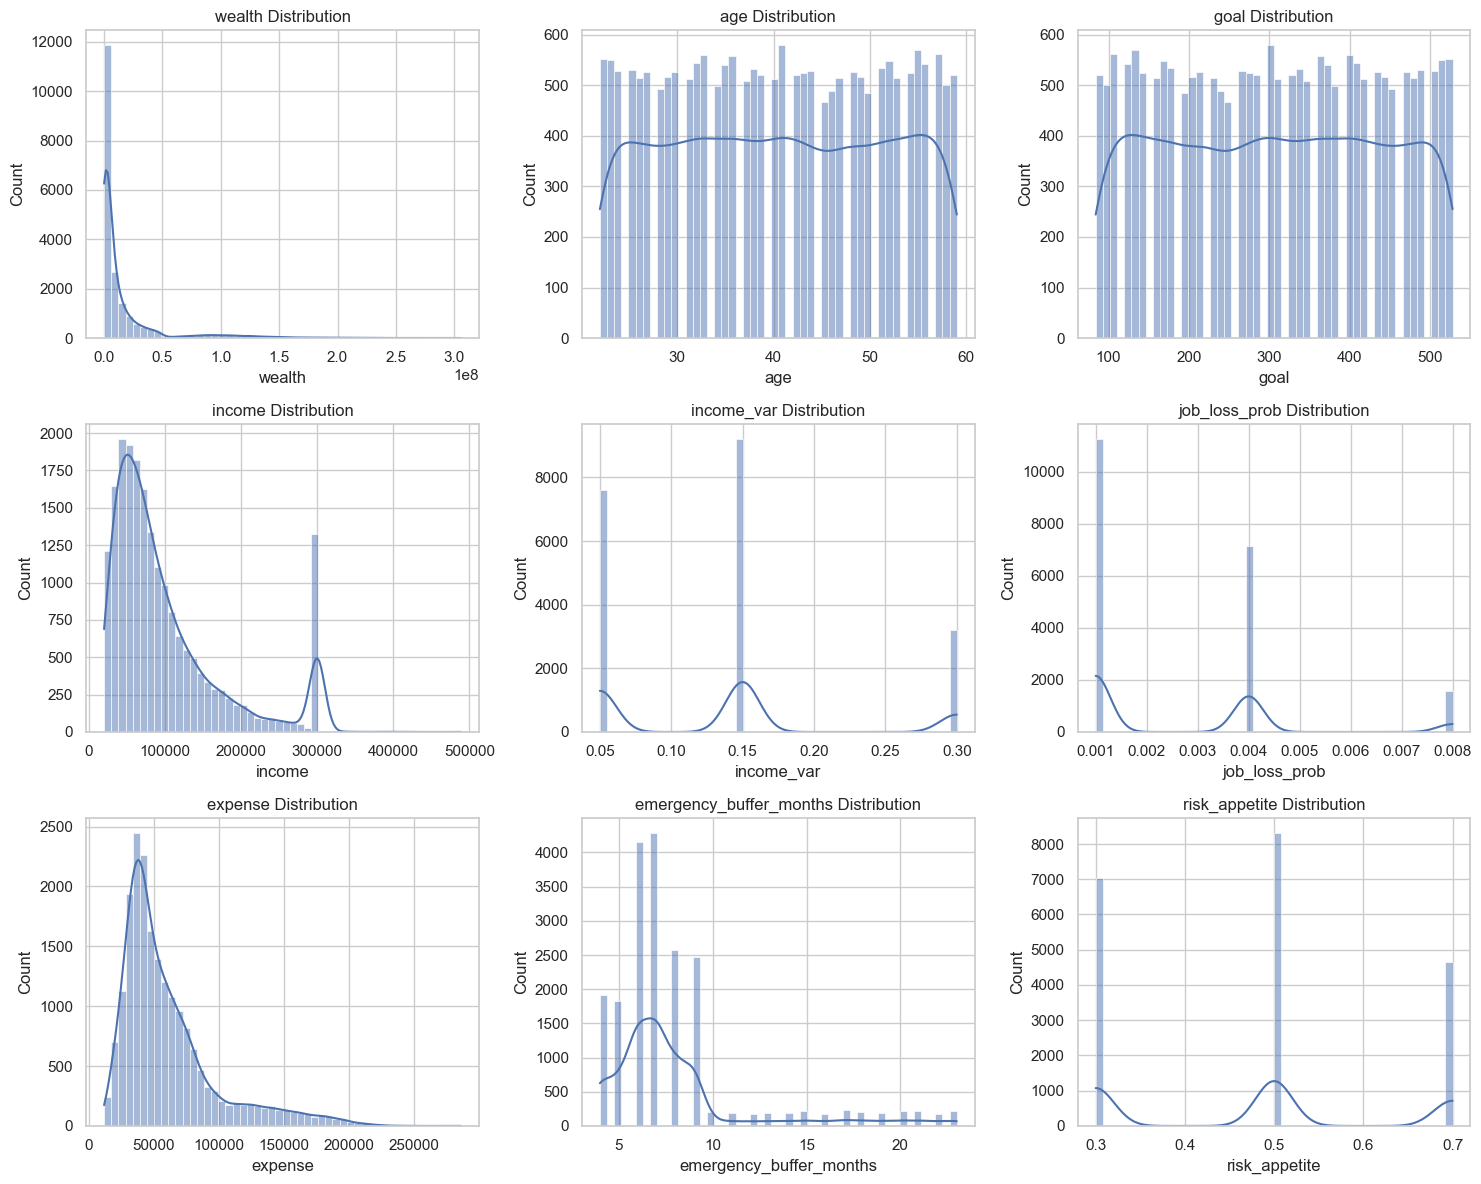

In [104]:
# User data distributions plot

def plot_user_distributions(df):
    cols = df.columns

    n_cols = 3
    n_rows = (len(cols) + 2) // 3

    plt.figure(figsize=(15, 4 * n_rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=50)
        plt.title(f"{col} Distribution")

    plt.tight_layout()
    plt.show()

plot_user_distributions(user_df)

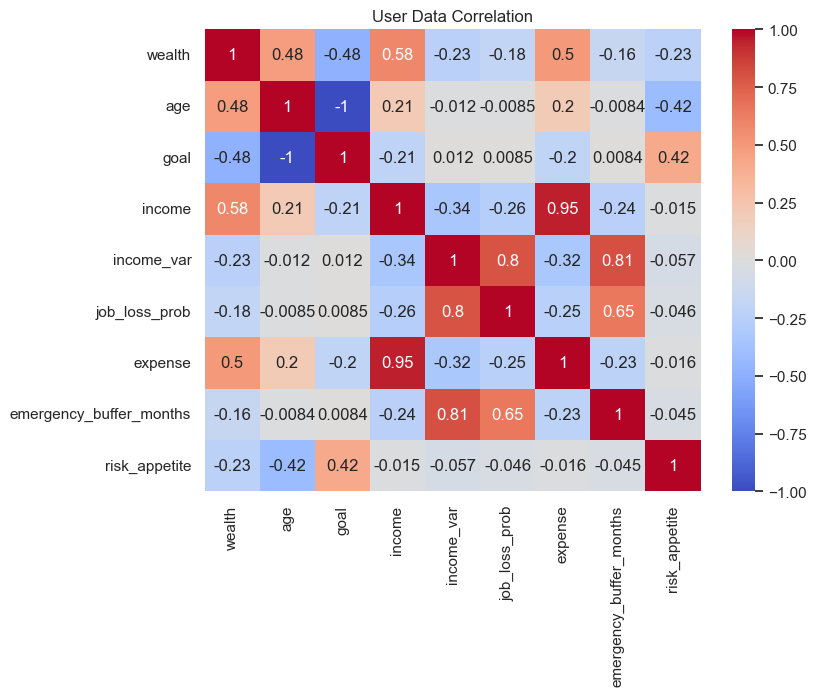

In [106]:
# User data correlations plots

plt.figure(figsize=(8, 6))
sns.heatmap(user_df.corr(), annot=True, cmap="coolwarm")
plt.title("User Data Correlation")
plt.show()

## Config

In [4]:
config = BaseConfig()

In [7]:
TIMESTEPS = 300_000
NUM_USERS = 100

## Train RL models

Using cpu device
Logging to ./outputs/tensorboard/ppo/PPO_71
-----------------------------
| time/              |      |
|    fps             | 1040 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 782          |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 0.0018603147 |
|    clip_fraction        | 0.0328       |
|    clip_range           | 0.1          |
|    entropy_loss         | -4.26        |
|    explained_variance   | 0.0162       |
|    learning_rate        | 0.0001       |
|    loss                 | 1.09         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00509     |
|    std                  | 1            

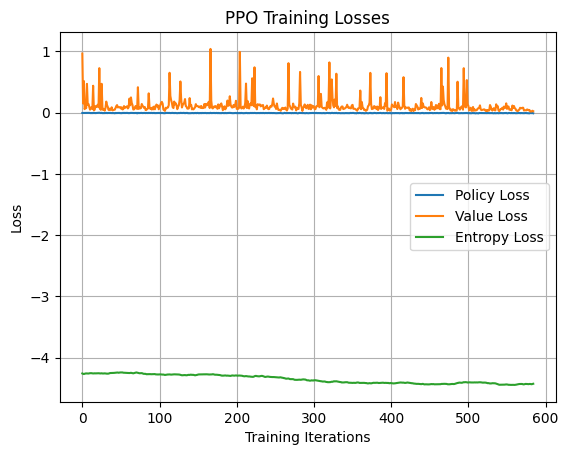

In [ ]:
ppo_model = train_ppo(market_df, user_df, config, TIMESTEPS)

Using cpu device
Logging to ./outputs/tensorboard/sac/SAC_9
---------------------------------
| time/              |          |
|    episodes        | 4        |
|    fps             | 28       |
|    time_elapsed    | 51       |
|    total_timesteps | 1488     |
| train/             |          |
|    actor_loss      | -21.6    |
|    critic_loss     | 0.5      |
|    ent_coef        | 0.871    |
|    ent_coef_loss   | -0.687   |
|    learning_rate   | 0.0001   |
|    n_updates       | 1387     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 8        |
|    fps             | 28       |
|    time_elapsed    | 90       |
|    total_timesteps | 2556     |
| train/             |          |
|    actor_loss      | -35      |
|    critic_loss     | 0.711    |
|    ent_coef        | 0.783    |
|    ent_coef_loss   | -1.2     |
|    learning_rate   | 0.0001   |
|    n_updates       | 2455     |
----------------------

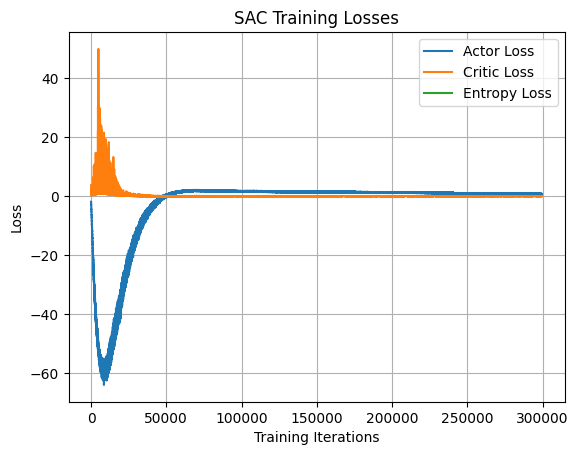

In [9]:
sac_model = train_sac(market_df, user_df, config, TIMESTEPS)

Using cpu device
Logging to ./outputs/tensorboard/td3/TD3_6
---------------------------------
| time/              |          |
|    episodes        | 4        |
|    fps             | 10       |
|    time_elapsed    | 101      |
|    total_timesteps | 1104     |
| train/             |          |
|    actor_loss      | 0.0162   |
|    critic_loss     | 0.00643  |
|    learning_rate   | 0.0001   |
|    n_updates       | 1003     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 8        |
|    fps             | 10       |
|    time_elapsed    | 225      |
|    total_timesteps | 2304     |
| train/             |          |
|    actor_loss      | -0.013   |
|    critic_loss     | 0.00802  |
|    learning_rate   | 0.0001   |
|    n_updates       | 2203     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 12       |
|    fps             |

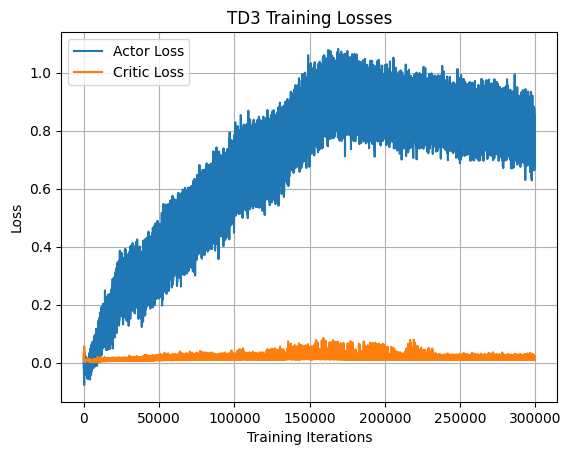

In [10]:
td3_model = train_td3(market_df, user_df, config, TIMESTEPS)

Using cpu device
Logging to ./outputs/tensorboard/ddpg/DDPG_5
---------------------------------
| time/              |          |
|    episodes        | 4        |
|    fps             | 29       |
|    time_elapsed    | 40       |
|    total_timesteps | 1200     |
| train/             |          |
|    actor_loss      | -0.0964  |
|    critic_loss     | 0.00401  |
|    learning_rate   | 0.0001   |
|    n_updates       | 1099     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 8        |
|    fps             | 28       |
|    time_elapsed    | 77       |
|    total_timesteps | 2201     |
| train/             |          |
|    actor_loss      | -0.144   |
|    critic_loss     | 0.00101  |
|    learning_rate   | 0.0001   |
|    n_updates       | 2100     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 12       |
|    fps            

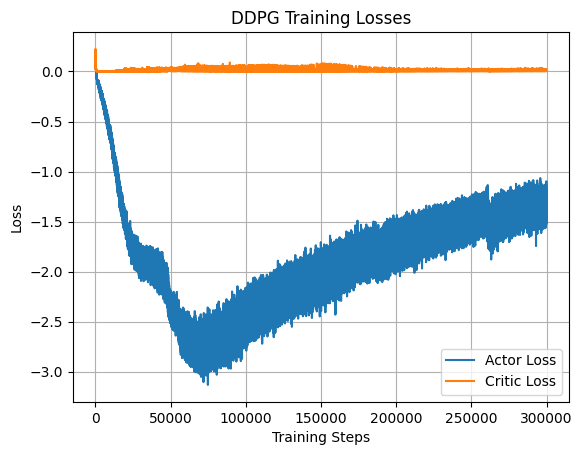

In [ ]:
ddpg_model = train_ddpg(market_df, user_df, config, TIMESTEPS)

Using cpu device
Logging to ./outputs/tensorboard/cvar/SAC_4
---------------------------------
| time/              |          |
|    episodes        | 4        |
|    fps             | 29       |
|    time_elapsed    | 35       |
|    total_timesteps | 1044     |
| train/             |          |
|    actor_loss      | -27.4    |
|    critic_loss     | 1.43     |
|    ent_coef        | 0.755    |
|    ent_coef_loss   | -1.37    |
|    learning_rate   | 0.0003   |
|    n_updates       | 943      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 8        |
|    fps             | 28       |
|    time_elapsed    | 98       |
|    total_timesteps | 2772     |
| train/             |          |
|    actor_loss      | -48.6    |
|    critic_loss     | 3.3      |
|    ent_coef        | 0.453    |
|    ent_coef_loss   | -3.81    |
|    learning_rate   | 0.0003   |
|    n_updates       | 2671     |
---------------------

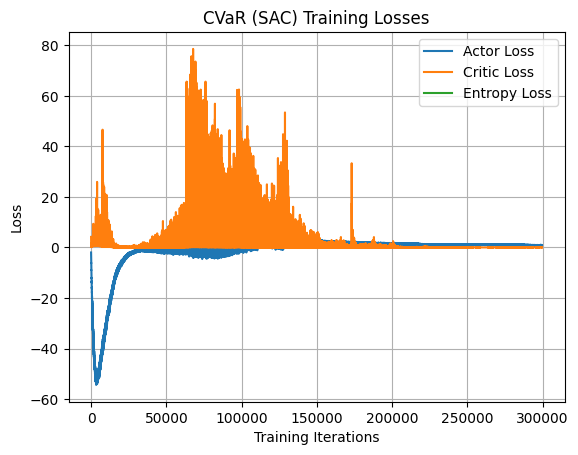

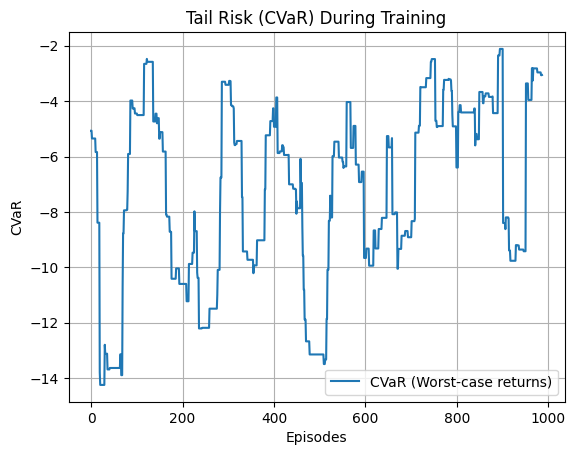

In [44]:
# cvar using SAC
cvar_model = train_cvar(market_df, user_df, config, TIMESTEPS)

## Train non-RL models

In [45]:
static_model = Static6040()
glide_model = GlidePath()

## Generate 100 fixed users

In [46]:
np.random.seed(42)

user_indices = np.random.choice(len(user_df), NUM_USERS, replace=False)

print("Selected Users:", user_indices)

Selected Users: [10650  2041  8668  1114 13902 11963 11072  3002 19771  8115  3525  7879
 16441 16296 12566  5252 19393 16796  8094   322  9923  7459 19024 17553
  9119 16421 16060 10120 19055  3649  3941 17880 16675 12630 11443 12157
 13835  3434 18739 17407 15440 10406  6517   971 16487 19730 13137  3669
 15983  4058 14976 15698 13829 13419   960 17744  9864 11263 15782 17196
  7554 10498 17059 17928  7085 14753  4519  3024 12121 18494  5483  1419
  6209 10742 16143 17617 14568   980  2783  7713 11518  8600 11640 18830
 12562 12751  6384  4807  6195 10648  7567 16397 17524  1346 13124 12673
 15455 14001 18621  2119]


## Evaluate all models on the same users

In [ ]:
models = {
    "static_6040": static_model,
    "glide_path": glide_model,
    "ppo": ppo_model,
    "sac": sac_model,
    "td3": td3_model,
    "ddpg": ddpg_model,
    "cvar": cvar_model
}

# evaluate on 100 users
user_indices = list(range(100))

all_results = {}

In [ ]:
for name, model in models.items():

    print(f"\n===== Evaluating {name} =====")

    results_per_user = []

    for user_idx in user_indices:

        res = evaluate(
            model=model,
            market_df=market_df,
            user_df=user_df,
            config=config,
            algo_name=name,
            num_episodes=1,              # 1 trajectory per user
            fixed_user_idx=user_idx,
            fixed_market_start=100
        )

        results_per_user.append(res)

    df = pd.DataFrame(results_per_user)

    final_wealths = df["final_wealth"].values   

    aggregated = {
        "avg_final_wealth": float(np.mean(final_wealths)),
        "median_final_wealth": float(np.median(final_wealths)),
        "wealth_std": float(np.std(final_wealths)),

        "avg_sharpe": float(df["avg_sharpe"].mean()),
        "avg_max_drawdown": float(df["avg_max_drawdown"].mean()),
        "ruin_probability": float(df["ruin_probability"].mean()),

        "cvar_0.1": float(
            np.mean(
                np.sort(final_wealths)[:max(1, int(0.1 * len(final_wealths)))]
            )
        ),

        "liquidity_shortfall_prob": float(df["liquidity_shortfall_prob"].mean())
    }

    aggregated["final_wealths"] = final_wealths.tolist()

    all_results[name] = aggregated


===== Evaluating static_6040 =====
Saved plot for user 0, episode 0
Saved plot for user 1, episode 0
Saved plot for user 2, episode 0
Saved plot for user 3, episode 0
Saved plot for user 4, episode 0
Saved plot for user 5, episode 0
Saved plot for user 6, episode 0
Saved plot for user 7, episode 0
Saved plot for user 8, episode 0
Saved plot for user 9, episode 0
Saved plot for user 10, episode 0
Saved plot for user 11, episode 0
Saved plot for user 12, episode 0
Saved plot for user 13, episode 0
Saved plot for user 14, episode 0
Saved plot for user 15, episode 0
Saved plot for user 16, episode 0
Saved plot for user 17, episode 0
Saved plot for user 18, episode 0
Saved plot for user 19, episode 0
Saved plot for user 20, episode 0
Saved plot for user 21, episode 0
Saved plot for user 22, episode 0
Saved plot for user 23, episode 0
Saved plot for user 24, episode 0
Saved plot for user 25, episode 0
Saved plot for user 26, episode 0
Saved plot for user 27, episode 0
Saved plot for user 28

## Aggregate results

In [80]:
df = pd.DataFrame(all_results).T

df = df[[
    "avg_final_wealth",
    "median_final_wealth",
    "wealth_std",
    "avg_sharpe",
    "avg_max_drawdown",
    "ruin_probability",
    "cvar_0.1",
    "liquidity_shortfall_prob"
]]

df = df.rename(columns={
    "avg_final_wealth": "Avg Wealth",
    "median_final_wealth": "Median Wealth",
    "wealth_std": "Wealth Std",
    "avg_sharpe": "Sharpe",
    "avg_max_drawdown": "Max DD",
    "ruin_probability": "Ruin Prob",
    "cvar_0.1": "CVaR (10%)",
    "liquidity_shortfall_prob": "Liquidity Shortfall"
})

print(df)

                   Avg Wealth     Median Wealth         Wealth Std    Sharpe  \
static_6040  662052399.491474  182727918.346832  1286040492.200826  0.197349   
glide_path   406613732.730867  113774137.897031  1136263023.821492  0.205261   
ppo          267047382.915784   59975469.757954   847277108.636108  0.144968   
sac          329558459.543354  123034543.122163   542345986.414535   0.28764   
td3          251948216.147093   57356511.203899   988868548.288512  0.185987   
ddpg         334145271.594011  125247055.177232   556007833.253672  0.440439   
cvar         462417932.060709  123200219.104888   943076382.037699  0.360723   

               Max DD Ruin Prob      CVaR (10%) Liquidity Shortfall  
static_6040 -0.644629      0.03  5954504.217008            0.001174  
glide_path  -0.565632       0.0  6257070.870091            0.000703  
ppo         -0.614885      0.05  1898592.614053             0.00902  
sac         -0.411807      0.04  1385054.849542            0.001698  
td3      

## Comparsion Plots

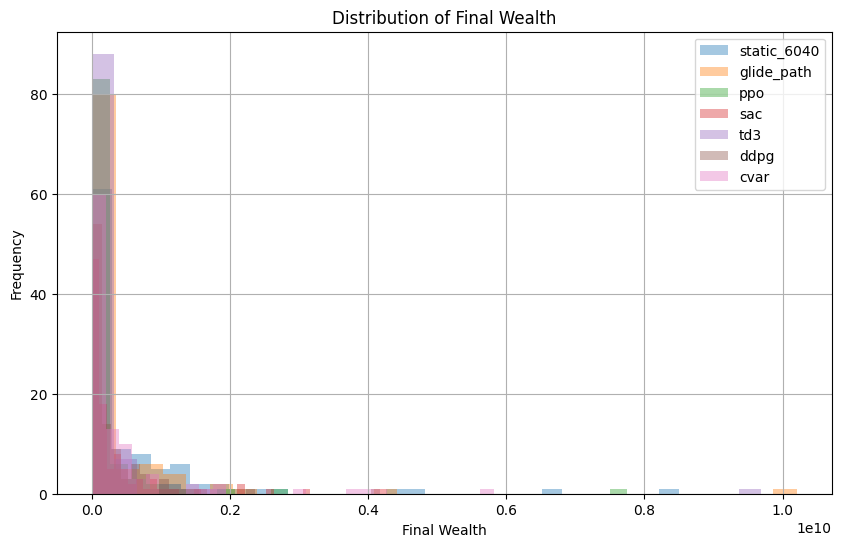

In [ ]:
# Final wealths comparison plot

plt.figure(figsize=(10,6))

for algo, res in all_results.items():
    plt.hist(res["final_wealths"], bins=30, alpha=0.4, label=algo)

plt.title("Distribution of Final Wealth")
plt.xlabel("Final Wealth")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

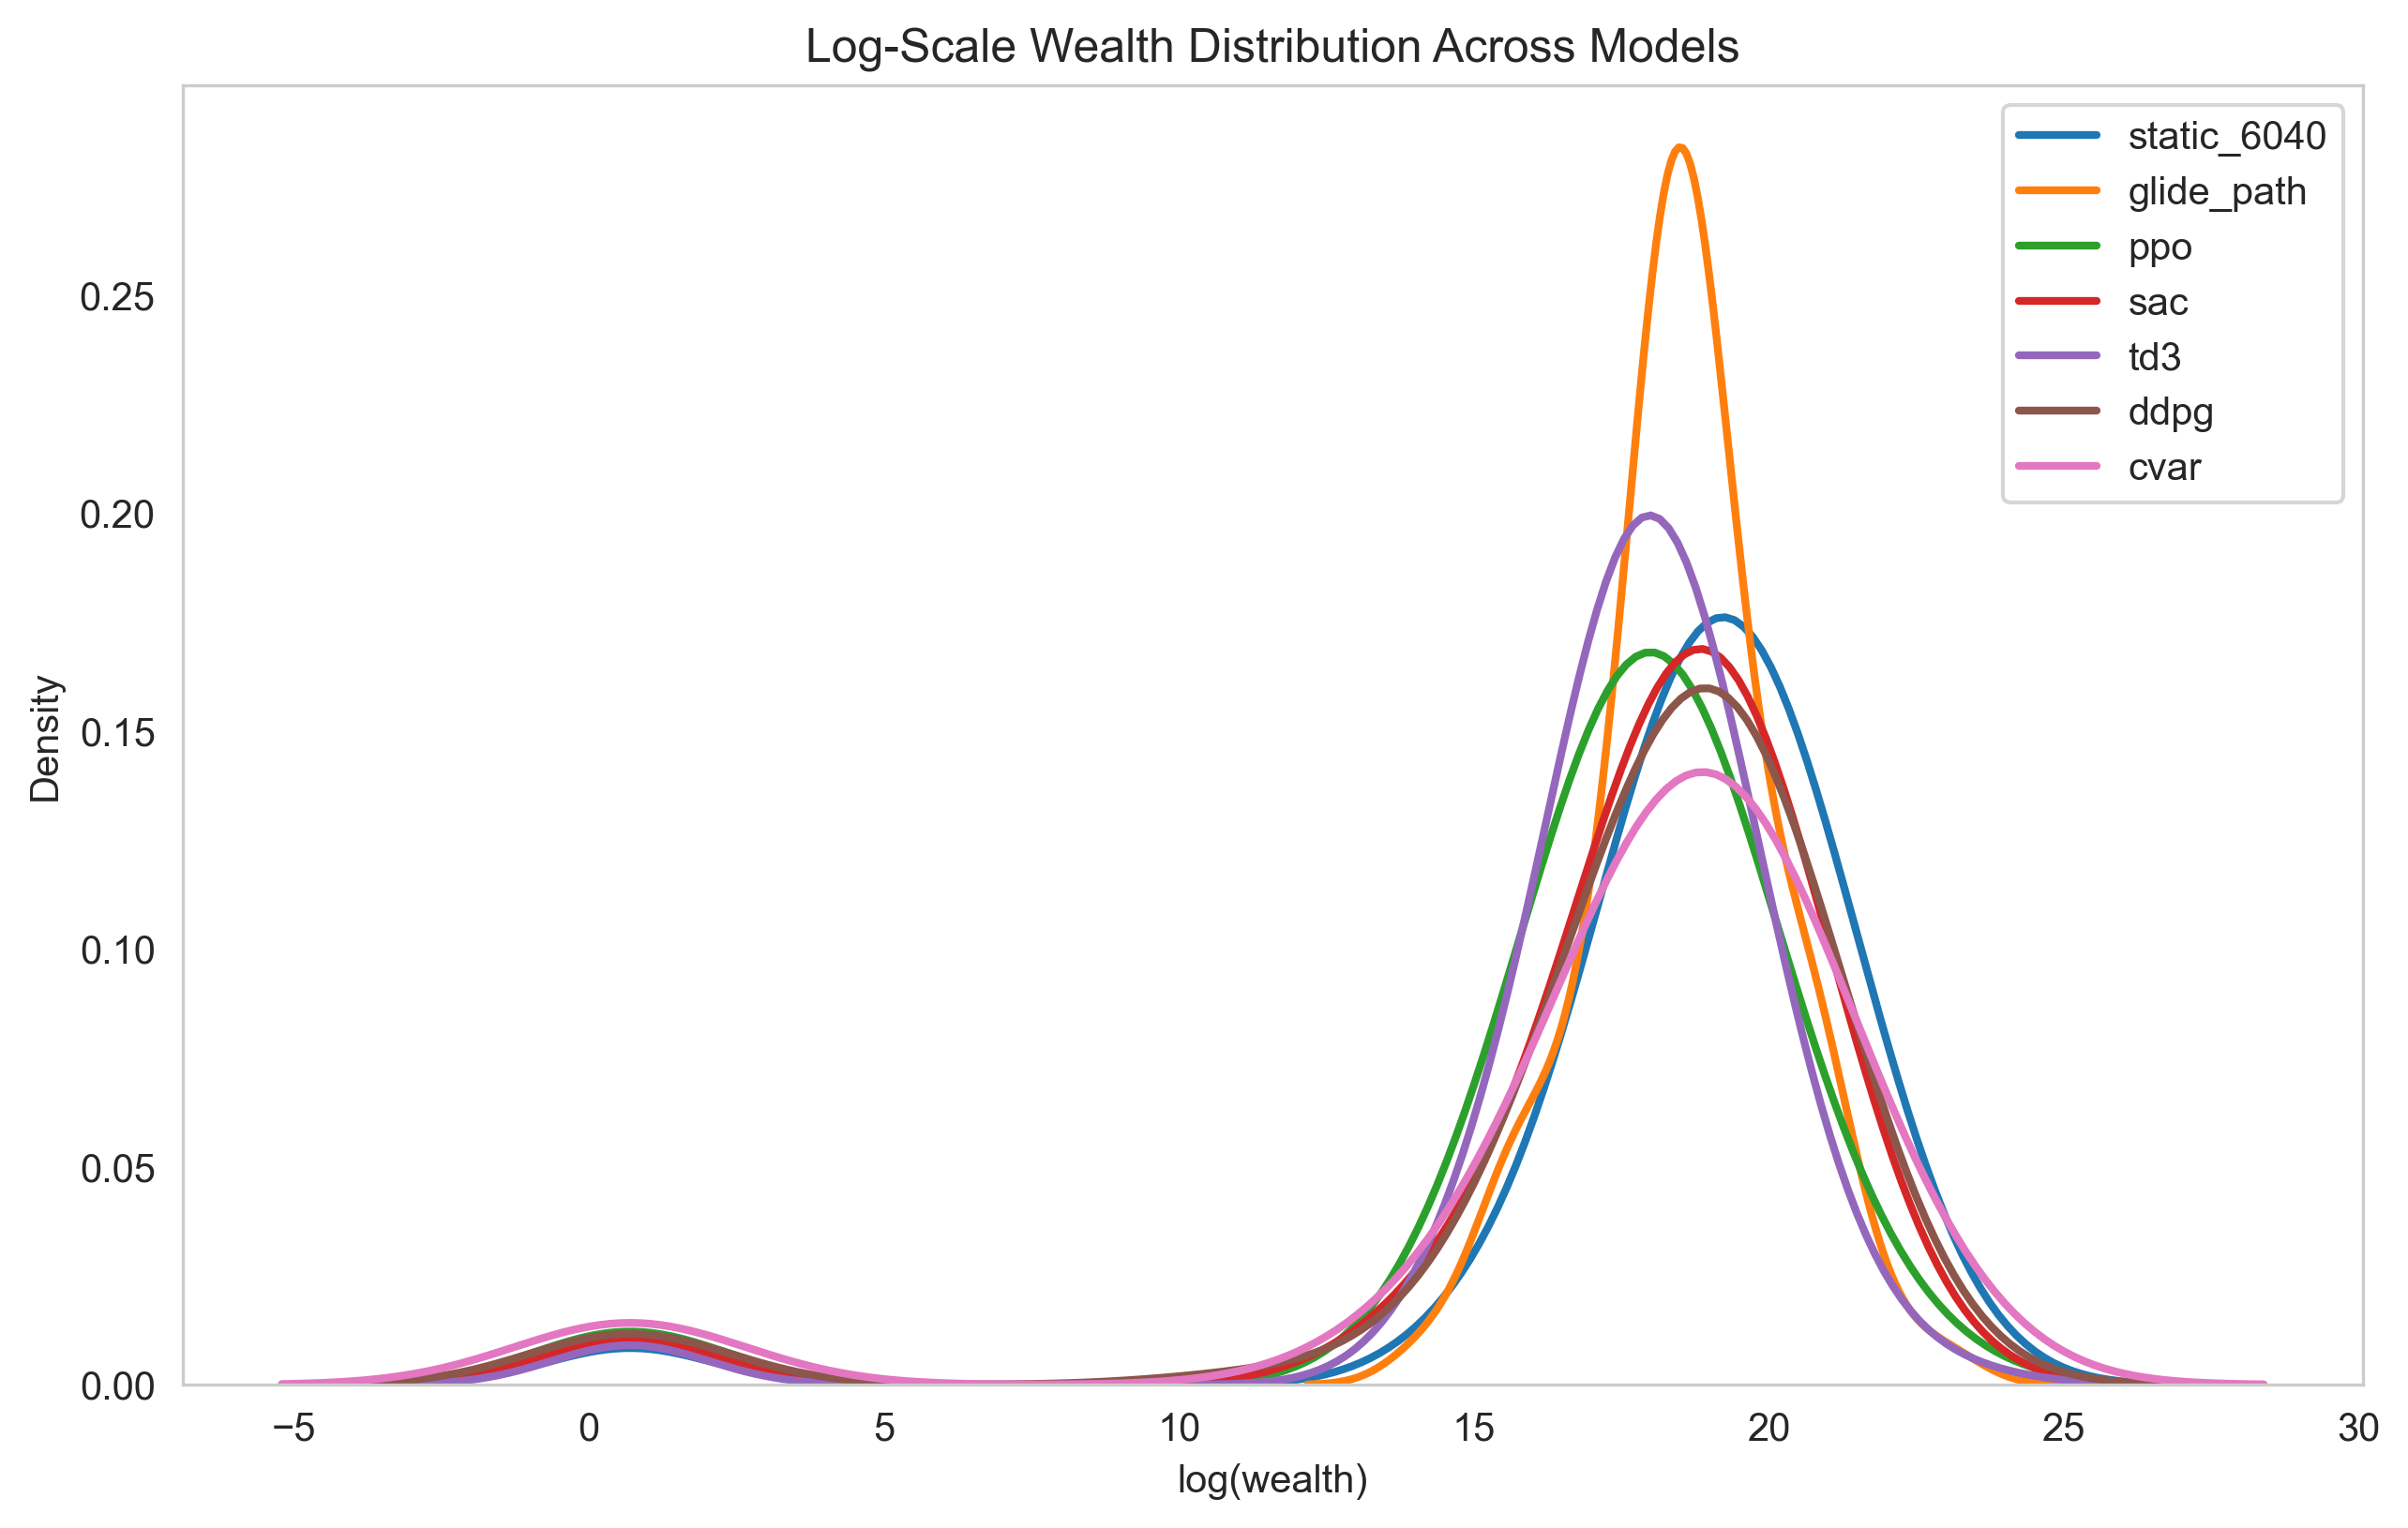

In [ ]:
# Log-scale final wealth distribution across users

plt.figure(figsize=(10,6), dpi=300)
sns.set_style("whitegrid")

for algo, res in all_results.items():
    wealths = np.array(res["final_wealths"])

    # 🔥 log transform (CRITICAL)
    wealths = np.log1p(wealths)

    sns.kdeplot(
        wealths,
        label=algo,
        linewidth=2
    )

plt.title("Log-Scale Wealth Distribution Across Models")
plt.xlabel("log(wealth)")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_12892\2251395465.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(wealth_data, labels=labels)


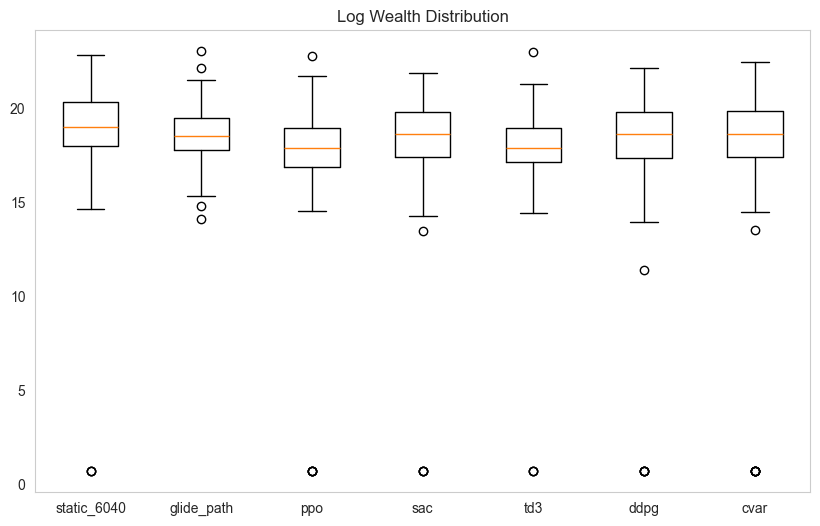

In [ ]:
# Log-scale box plots for final wealths across users

wealth_data = []
labels = []

sns.set_style("whitegrid")

for algo, res in all_results.items():
    wealth_data.append(np.log1p(res["final_wealths"]))
    labels.append(algo)

plt.figure(figsize=(10,6))
plt.boxplot(wealth_data, labels=labels)
plt.title("Log Wealth Distribution")
plt.grid()
plt.show()

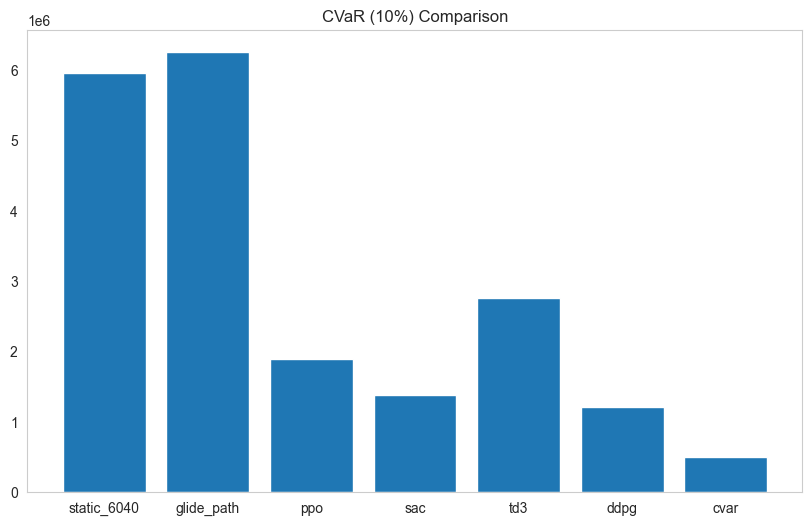

In [ ]:
# CVaR compariosn across users

cvars = [res["cvar_0.1"] for res in all_results.values()]
labels = list(all_results.keys())

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))
plt.bar(labels, cvars)
plt.title("CVaR (10%) Comparison")
plt.grid()
plt.show()

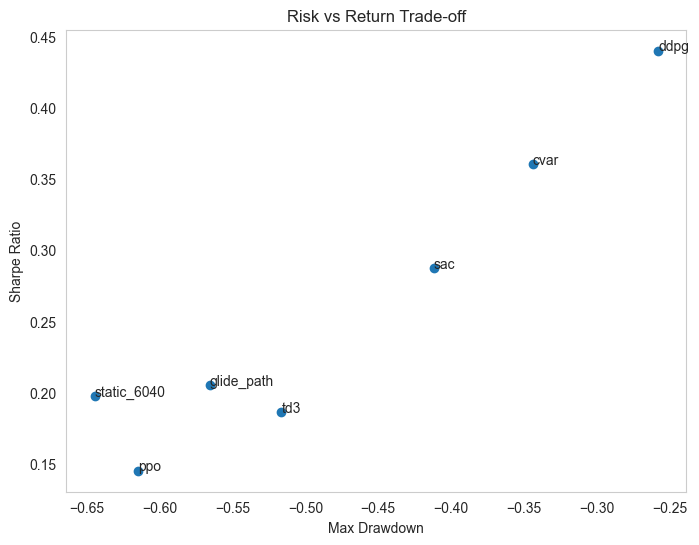

In [ ]:
# Sharpe ratio vs drawdown plot to measure risk vs return tradeoff

sharpe = [res["avg_sharpe"] for res in all_results.values()]
drawdown = [res["avg_max_drawdown"] for res in all_results.values()]

labels = list(all_results.keys())

sns.set_style("whitegrid")

plt.figure(figsize=(8,6))
plt.scatter(drawdown, sharpe)

for i, label in enumerate(labels):
    plt.annotate(label, (drawdown[i], sharpe[i]))

plt.xlabel("Max Drawdown")
plt.ylabel("Sharpe Ratio")
plt.title("Risk vs Return Trade-off")
plt.grid()
plt.show()